# Corporate Credit Rating — Regression Track
## Predicting Numeric Credit Rating Score (Rating_Score)

This notebook loads the preprocessed corporate financial dataset and builds, compares, tunes, and evaluates 10 regression models to predict corporate credit rating scores from financial indicators.

## 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error
)

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Preprocessed Regression Dataset

Loading the preprocessed, encoded, and scaled training and test sets generated by `preprocessing.ipynb`.

In [2]:
data_dir = '../data' if os.path.exists('../data') else 'data'

train_df = pd.read_csv(os.path.join(data_dir, 'train_regression_preprocessed.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_regression_preprocessed.csv'))

# Features and Targets
X_train_r = train_df.drop(columns=['Rating_Score'])
y_train_r = train_df['Rating_Score']

X_test_r = test_df.drop(columns=['Rating_Score'])
y_test_r = test_df['Rating_Score']

# Scaled feature arrays for model fitting
X_train_r_scaled = X_train_r.values
X_test_r_scaled = X_test_r.values

print(f'Loaded preprocessed regression data from {data_dir}:')
print(f'Training set: X = {X_train_r.shape}, y = {y_train_r.shape}')
print(f'Testing set:  X = {X_test_r.shape}, y = {y_test_r.shape}')

Loaded preprocessed regression data from ../data:
Training set: X = (6244, 29), y = (6244,)
Testing set:  X = (1561, 29), y = (1561,)


## 15. Regression Models

In [3]:
reg_models = {}
reg_results = []

def add_reg_result(name, model, preds):
    reg_models[name] = model

    r2 = r2_score(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    mae = mean_absolute_error(y_test_r, preds)

    reg_results.append([name, r2, rmse, mae])

    print(name)
    print("R2:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print()

### 15.1 Linear Regression

In [4]:
lr_model = LinearRegression()
lr_model.fit(X_train_r_scaled, y_train_r)
lr_preds = lr_model.predict(X_test_r_scaled)

add_reg_result("Linear Regression", lr_model, lr_preds)

Linear Regression
R2: 0.3451059574627353
RMSE: 3.038911424851244
MAE: 2.3091504487901986



### 15.2 Ridge Regression

In [5]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_r_scaled, y_train_r)
ridge_preds = ridge_model.predict(X_test_r_scaled)

add_reg_result("Ridge Regression", ridge_model, ridge_preds)

Ridge Regression
R2: 0.3458233887127693
RMSE: 3.037246416996063
MAE: 2.3086340615770773



### 15.3 Lasso Regression

In [6]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_r_scaled, y_train_r)
lasso_preds = lasso_model.predict(X_test_r_scaled)

add_reg_result("Lasso Regression", lasso_model, lasso_preds)

Lasso Regression
R2: 0.3362264350790789
RMSE: 3.0594439291803006
MAE: 2.362941561247285



### 15.4 ElasticNet Regression

In [7]:
en_model = ElasticNet(alpha=0.1)
en_model.fit(X_train_r_scaled, y_train_r)
en_preds = en_model.predict(X_test_r_scaled)

add_reg_result("ElasticNet Regression", en_model, en_preds)

ElasticNet Regression
R2: 0.34391604380894003
RMSE: 3.0416709560925455
MAE: 2.3465758608271248



### 15.5 Polynomial Regression

In [8]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_r_scaled)
X_test_poly = poly.transform(X_test_r_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_r)
poly_preds = poly_model.predict(X_test_poly)

# Store the polynomial model separately
poly_r2 = r2_score(y_test_r, poly_preds)
poly_rmse = np.sqrt(mean_squared_error(y_test_r, poly_preds))
poly_mae = mean_absolute_error(y_test_r, poly_preds)

reg_models["Polynomial Regression"] = poly_model
reg_results.append(["Polynomial Regression", poly_r2, poly_rmse, poly_mae])

print("Polynomial Regression")
print("R2:", poly_r2)
print("RMSE:", poly_rmse)
print("MAE:", poly_mae)

Polynomial Regression
R2: 0.4990728245410304
RMSE: 2.657784831464533
MAE: 2.0591568399056737


### Polynomial Degree Comparison

In [9]:
degree_results = []

for degree in [1, 2]:
    p = PolynomialFeatures(degree=degree)
    xtr_p = p.fit_transform(X_train_r_scaled)
    xte_p = p.transform(X_test_r_scaled)

    m = LinearRegression()
    m.fit(xtr_p, y_train_r)
    pred = m.predict(xte_p)

    degree_results.append([
        degree,
        r2_score(y_test_r, pred),
        np.sqrt(mean_squared_error(y_test_r, pred))
    ])

pd.DataFrame(
    degree_results,
    columns=['Degree', 'R2', 'RMSE']
)

,Degree,R2,RMSE
0,1,0.345106,3.038911
1,2,0.499073,2.657785


### 15.6 Decision Tree Regressor

In [12]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_r_scaled, y_train_r)
dt_preds = dt_model.predict(X_test_r_scaled)

add_reg_result("Decision Tree Regressor", dt_model, dt_preds)

Decision Tree Regressor
R2: 0.42312507325712023
RMSE: 2.852156511292421
MAE: 2.205741012163194



### 15.7 Random Forest Regressor

In [13]:
rf_model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_r_scaled, y_train_r)
rf_preds = rf_model.predict(X_test_r_scaled)

add_reg_result("Random Forest Regressor", rf_model, rf_preds)

Random Forest Regressor
R2: 0.7207214132732869
RMSE: 1.984501086687265
MAE: 1.4505999074232012



### 15.8 Gradient Boosting Regressor

In [14]:
gb_model = GradientBoostingRegressor(
    n_estimators=50, random_state=42
)
gb_model.fit(X_train_r_scaled, y_train_r)
gb_preds = gb_model.predict(X_test_r_scaled)

add_reg_result("Gradient Boosting Regressor", gb_model, gb_preds)

Gradient Boosting Regressor
R2: 0.5314318931221971
RMSE: 2.5705075541711326
MAE: 1.980698558793103



### 15.9 Support Vector Regressor

In [15]:
svr_model = SVR(kernel='rbf', C=1.0)
svr_model.fit(X_train_r_scaled, y_train_r)
svr_preds = svr_model.predict(X_test_r_scaled)

add_reg_result("Support Vector Regressor", svr_model, svr_preds)

Support Vector Regressor
R2: 0.5475295953598658
RMSE: 2.5259666422733402
MAE: 1.887038740750566



### 15.10 K-Nearest Neighbors Regressor

In [16]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_r_scaled, y_train_r)
knn_preds = knn_model.predict(X_test_r_scaled)

add_reg_result("KNN Regressor", knn_model, knn_preds)

KNN Regressor
R2: 0.6382461750685362
RMSE: 2.2585987730628414
MAE: 1.5663036515054451



## 16. Regression Comparison

In [17]:
results_df = pd.DataFrame(
    reg_results,
    columns=['Model', 'R2', 'RMSE', 'MAE']
)

results_df = results_df.sort_values(
    by='R2', ascending=False
).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.720721,1.984501,1.450600
1,KNN Regressor,0.638246,2.258599,1.566304
2,Support Vector Regressor,0.547530,2.525967,1.887039
3,Gradient Boosting Regressor,0.531432,2.570508,1.980699
4,Polynomial Regression,0.499073,2.657785,2.059157
5,Decision Tree Regressor,0.423125,2.852157,2.205741
6,Decision Tree Regressor,0.423125,2.852157,2.205741
7,Ridge Regression,0.345823,3.037246,2.308634
8,Linear Regression,0.345106,3.038911,2.309150
9,ElasticNet Regression,0.343916,3.041671,2.346576


### Observation

The table ranks all ten regression algorithms using the same held-out test set. A higher R² and lower RMSE/MAE indicate better regression performance.

## 16.1 Linear Regression Coefficients

In [29]:
coef_table = pd.Series(
    lr_model.coef_,
    index=X_train_r.columns
).sort_values(key=abs, ascending=False)

coef_table.head(10)

EBIT Margin                   4.870948
Operating Margin             -4.148679
ROI - Return On Investment    1.799910
Long-term Debt / Capital     -1.442693
Average Profit Margin        -1.080679
ROA - Return On Assets       -1.037607
Pre-Tax Profit Margin         0.853470
Current Ratio                -0.781529
EBITDA Margin                -0.624528
Net Profit Margin             0.588865
dtype: float64


### Observation

A positive coefficient means the feature increases the predicted rating score when other features are kept constant. A negative coefficient means the opposite. The size of the coefficient shows its relative effect after scaling.


## 17. Hyperparameter Tuning

In [18]:
# Tune KNN Regressor
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

knn_search = GridSearchCV(
    KNeighborsRegressor(),
    knn_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

knn_search.fit(X_train_r_scaled, y_train_r)

knn_tuned_preds = knn_search.predict(X_test_r_scaled)
knn_tuned_r2 = r2_score(y_test_r, knn_tuned_preds)

print("KNN best parameters:", knn_search.best_params_)

print("KNN before tuning R2:", results_df.loc[
    results_df['Model'] == 'KNN Regressor', 'R2'
].iloc[0])

print("KNN after tuning R2:", knn_tuned_r2)

KNN best parameters: {'n_neighbors': 3}
KNN before tuning R2: 0.6382461750685362
KNN after tuning R2: 0.661090441923528


In [19]:
# Tune Random Forest
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_search.fit(X_train_r_scaled, y_train_r)

rf_tuned_preds = rf_search.predict(X_test_r_scaled)
rf_tuned_r2 = r2_score(y_test_r, rf_tuned_preds)

print("Random Forest best parameters:", rf_search.best_params_)
print("Random Forest before tuning R2:", results_df.loc[
    results_df['Model'] == 'Random Forest Regressor', 'R2'
].iloc[0])
print("Random Forest after tuning R2:", rf_tuned_r2)

Random Forest best parameters: {'max_depth': None, 'n_estimators': 100}
Random Forest before tuning R2: 0.7207214132732869
Random Forest after tuning R2: 0.7883979760180991


### Observation

GridSearchCV checks different parameter combinations using cross-validation. The best parameter values are selected using training data, and the tuned models are then checked on the held-out test set.

## 18. 5-Fold Cross Validation for the Two Best Models

In [20]:
best_two = results_df.head(2)['Model'].tolist()

print("Two best models:", best_two)
print()

for name in best_two:
    if name == "Random Forest Regressor":
        model = rf_search.best_estimator_
        X_cv = X_train_r_scaled

    elif name == "KNN Regressor":
        model = knn_search.best_estimator_
        X_cv = X_train_r_scaled

    else:
        model = reg_models[name]
        X_cv = X_train_r_scaled

    scores = cross_val_score(
        model,
        X_cv,
        y_train_r,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    print(name)
    print("CV R2 scores:", scores)
    print("Mean CV R2:", scores.mean())
    print("Std:", scores.std())
    print()

Two best models: ['Random Forest Regressor', 'KNN Regressor']

Random Forest Regressor
CV R2 scores: [0.7755581  0.77446737 0.74631143 0.78313622 0.78392254]
Mean CV R2: 0.7726791305977926
Std: 0.013729581595104767

KNN Regressor
CV R2 scores: [0.71303612 0.70005792 0.66722403 0.67738754 0.67193279]
Mean CV R2: 0.685927683585912
Std: 0.017624691598300418



## 19. Best Regression Model Visualisation

In [22]:
## Best Regression Model Visualisation

# Select the best model from all 10 algorithms based on R2
best_model_name = results_df.iloc[0]['Model']

# Get predictions for the best model
if best_model_name == "Random Forest Regressor":
    best_preds = rf_tuned_preds
elif best_model_name == "KNN Regressor":
    best_preds = knn_tuned_preds
elif best_model_name == "Polynomial Regression":
    best_preds = poly_preds
else:
    best_preds = reg_models[best_model_name].predict(X_test_r_scaled)

print("Best model among all 10 algorithms:", best_model_name)

Best model among all 10 algorithms: Random Forest Regressor


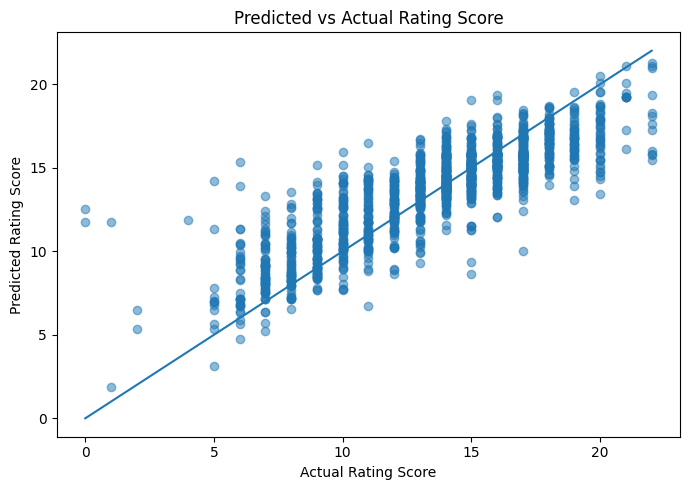

In [34]:
# Predicted vs Actual
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, best_preds, alpha=0.5)
plt.plot(
    [y_test_r.min(), y_test_r.max()],
    [y_test_r.min(), y_test_r.max()]
)
plt.title('Predicted vs Actual Rating Score')
plt.xlabel('Actual Rating Score')
plt.ylabel('Predicted Rating Score')
plt.tight_layout()
plt.show()

### Observation

Points closer to the diagonal line represent more accurate predictions. A strong regression model should keep most predictions close to this line.

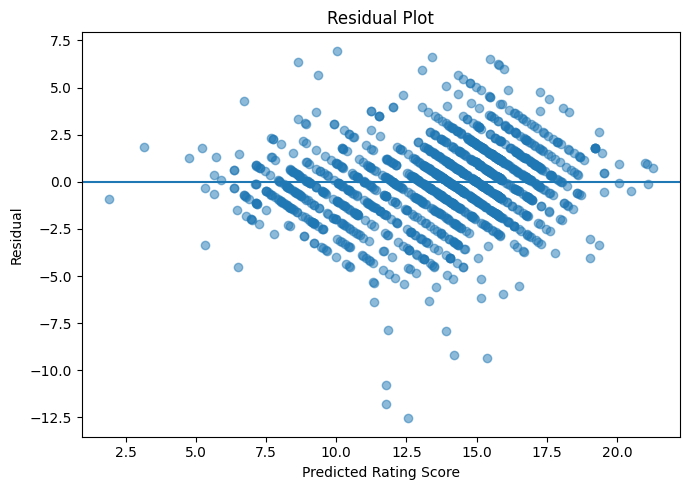

In [35]:
# Residual plot
residuals = y_test_r - best_preds

plt.figure(figsize=(7, 5))
plt.scatter(best_preds, residuals, alpha=0.5)
plt.axhline(0)
plt.title('Residual Plot')
plt.xlabel('Predicted Rating Score')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

### Observation

Residuals should be reasonably spread around zero without a clear pattern. Large residuals show observations where the model has difficulty predicting the rating score.

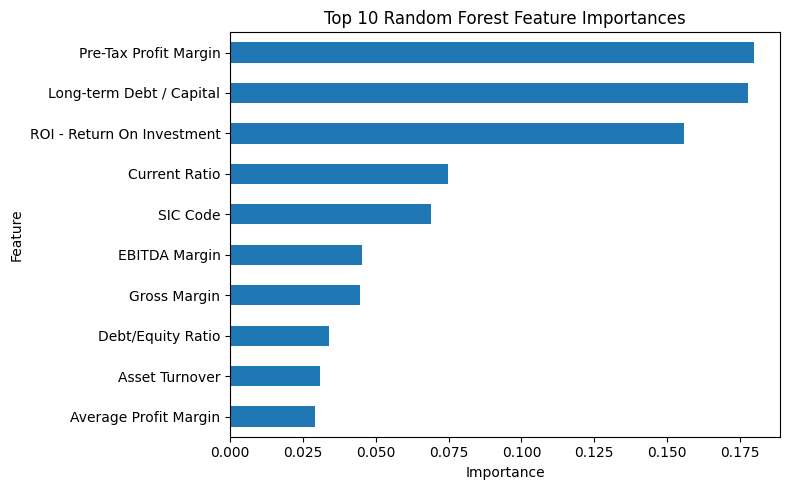

In [36]:
# Feature importance for the Random Forest
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_r.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Observation

The feature importance plot shows which financial variables contribute most to the Random Forest's predictions. Importance indicates the model's use of a feature; it does not by itself prove causation.